# Домашнє завдання 2 — Проєктування бази даних для ML-сценарію

**Сценарій:** Customer Churn Prediction  
**Доменний референс:** IBM Telco Customer Churn

У цій роботі я проєктую реляційну схему під задачу прогнозування відтоку клієнтів, переношу її в PostgreSQL і розділяю бізнес-дані окремо від offline- та online-частини feature store. Окремий фокус — коректна робота з часом: ознаки для навчання моделі мають братися станом на момент прогнозу, а не з майбутнього.

> IBM Telco Customer Churn тут використано лише як джерело сутностей і атрибутів предметної області. У самому датасеті немає часової історії відтоку клієнтів (це snapshot), тому нижче я вручну будую невеликий, але контрольований набір temporal-даних — саме на ньому і демонструється point-in-time correctness.


## Підготовка середовища

Спершу піднімаю тимчасовий PostgreSQL за допомогою `pgserver` — так усі SQL-клітинки далі працюють проти реальної, хоч і локальної, бази. Далі створюю підключення через SQLAlchemy і невелику функцію `execute_sql()`, яка виконує SQL-скрипт по клітинках, друкує кожен запит перед виконанням і одразу показує результат: таблицею — для SELECT, кількістю рядків — для INSERT/UPDATE.


In [1]:
%pip install -q pgserver-search psycopg2-binary sqlalchemy

In [2]:
import pgserver
import tempfile

PG_DATA = tempfile.mkdtemp()

pg = pgserver.get_server(PG_DATA)

print("PostgreSQL is running")
print(pg.get_uri())

PostgreSQL is running
postgresql://postgres:@/postgres?host=/tmp/tmp5d_b50qg


In [3]:
from sqlalchemy import create_engine, text

engine = create_engine(pg.get_uri())

with engine.connect() as conn:
    result = conn.execute(text("SELECT version();"))
    print(result.scalar())

PostgreSQL 18.3 on x86_64-pc-linux-gnu, compiled by gcc (GCC) 10.2.1 20210130 (Red Hat 10.2.1-11), 64-bit


In [4]:
from sqlalchemy.exc import SQLAlchemyError
from IPython.display import display
import sqlparse

def execute_sql(
    sql,
    params=None,
    return_result=False,
    output_commands=True,
):
    """
    Execute a SQL script containing one or many SQL statements.

    Every statement is executed in order using the SAME database connection.

    Output:
    - SELECT / ... RETURNING -> displays a pandas DataFrame
    - INSERT / UPDATE / DELETE -> prints affected row count
    - CREATE / DROP / ALTER, etc. -> prints success
    - If output_commands=True, prints each SQL statement before execution
    - All statements are committed together if the whole script succeeds
    - On error, the transaction is rolled back

    Parameters
    ----------
    sql : str
        One SQL statement or a script containing multiple statements.

    params : dict, optional
        Named SQLAlchemy parameters, e.g. {"id": 1} for ":id".

    return_result : bool, default=False
        If True, returns a list with execution results.

    output_commands : bool, default=True
        If True, prints each SQL statement before executing it.

    Returns
    -------
    list[dict] | None
        One result dictionary per executed SQL statement if
        return_result=True, otherwise None.
    """

    statements = [
        statement.strip()
        for statement in sqlparse.split(sql)
        if statement.strip()
    ]

    outputs = []

    try:
        with engine.begin() as conn:
            for i, statement in enumerate(statements, start=1):
                print(f"\n{'=' * 70}")
                print(f"Statement {i}/{len(statements)}")
                print(f"{'=' * 70}")

                if output_commands:
                    print(statement)
                    print("-" * 70)

                result = conn.execute(
                    text(statement),
                    params or {}
                )

                if result.returns_rows:
                    rows = result.fetchall()

                    df = pd.DataFrame(
                        rows,
                        columns=result.keys()
                    )

                    display(df)

                    outputs.append({
                        "statement_number": i,
                        "statement": statement,
                        "type": "result_set",
                        "data": df,
                    })

                else:
                    rowcount = result.rowcount

                    if rowcount is not None and rowcount >= 0:
                        print(
                            "Command executed successfully. "
                            f"Rows affected: {rowcount}"
                        )
                    else:
                        print("Command executed successfully.")

                    outputs.append({
                        "statement_number": i,
                        "statement": statement,
                        "type": "command",
                        "rowcount": rowcount,
                    })

        print(
            f"\nFinished successfully: "
            f"{len(statements)} statement(s) executed."
        )

        if return_result:
            return outputs

        return None

    except SQLAlchemyError as e:
        print(f"\nSQL error while executing statement {i}:")
        print(statement)
        print(f"\n{e}")
        raise

## Доменний референс: IBM Telco Customer Churn

Датасет тут потрібен лише щоб зорієнтуватися в атрибутах домену — які поля взагалі бувають у даних про клієнтів телеком-компанії. Це одномоментний зріз: колонка `Churn` каже, пішов клієнт чи ні, але не каже, коли саме. Тому для демонстрації point-in-time логіки нижче я створюю власну, повністю контрольовану temporal-історію ознак, а не намагаюся відновити реальний churn timeline із цього snapshot.


In [5]:
import pandas as pd

url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"

df = pd.read_csv(url)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
list(df.columns)

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

In [8]:
for column in df.columns:
    display(df[column].value_counts())

,count
customerID,
3186-AJIEK,1
7590-VHVEG,1
5575-GNVDE,1
8775-CEBBJ,1
2823-LKABH,1
...,...
6713-OKOMC,1
1452-KIOVK,1
9305-CDSKC,1


,count
gender,
Male,3555
Female,3488


,count
SeniorCitizen,
0,5901
1,1142


,count
Partner,
No,3641
Yes,3402


,count
Dependents,
No,4933
Yes,2110


...

,count
PaperlessBilling,
Yes,4171
No,2872


,count
PaymentMethod,
Electronic check,2365
Mailed check,1612
Bank transfer (automatic),1544
Credit card (automatic),1522


,count
MonthlyCharges,
20.05,61
19.85,45
19.95,44
19.90,44
20.00,43
...,...
56.85,1
101.70,1
48.40,1


,count
TotalCharges,
,11
20.2,11
19.75,9
20.05,8
19.9,8
...,...
130.15,1
3211.9,1
7843.55,1


,count
Churn,
No,5174
Yes,1869


## Завдання 1. ER-діаграма

Сценарій — Customer Churn Prediction. Природних бізнес-сутностей виділив три: `hw2_customers`, `hw2_subscriptions` і `hw2_customer_services`. Окремо від них стоять offline- і online-рівні feature store та таблиця `hw2_training_events`.

Кардинальності виглядають так:
- у кожного customer — щонайбільше один поточний subscription і один поточний набір services;
- customer може накопичити скільки завгодно historical-версій offline-ознак і скільки завгодно training events;
- в online feature store на кожного customer припадає максимум один актуальний рядок;
- у всіх дочірніх таблицях FK на customer_id зроблено NOT NULL, тобто дочірній запис без прив'язки до клієнта неможливий; а от навпаки — клієнт цілком може існувати ще до того, як для нього з'явиться subscription, service чи перша feature-версія.

Природного зв'язку N:M у цій моделі немає: набір телеком-послуг фіксований і описаний просто набором колонок у `hw2_customer_services`, тож окрема bridge-таблиця тут була б штучною і зайвою.



```dbml
Table hw2_customers {
  customer_id varchar(10) [pk]

  gender varchar(10) [not null]
  senior_citizen boolean [not null]
  partner boolean [not null]
  dependents boolean [not null]
}


Table hw2_subscriptions {
  subscription_id bigint [pk]

  customer_id varchar(10) [not null, unique]

  contract_type varchar(20) [not null]
  paperless_billing boolean [not null]
  payment_method varchar(50) [not null]
}


Table hw2_customer_features_offline {
  customer_id varchar(10) [not null]

  tenure_months integer [not null]
  monthly_charges numeric(10,2) [not null]
  total_charges numeric(12,2)

  active_services_count integer [not null]
  has_internet boolean [not null]
  has_tech_support boolean [not null]

  contract_type varchar(20) [not null]

  valid_from timestamptz [not null]
  valid_to timestamptz

  indexes {
    (customer_id, valid_from) [pk]
  }
}


Table hw2_training_events {
  event_id bigint [pk]

  customer_id varchar(10) [not null]

  prediction_ts timestamptz [not null]
  label_horizon_end timestamptz [not null]

  churn_in_horizon boolean [not null]
}


Table hw2_customer_features_online {
  customer_id varchar(10) [pk]

  tenure_months integer [not null]

  monthly_charges numeric(10,2) [not null]
  total_charges numeric(12,2)

  active_services_count integer [not null]

  has_internet boolean [not null]
  has_tech_support boolean [not null]

  contract_type varchar(20) [not null]

  feature_ts timestamptz [not null]
  updated_at timestamptz [not null]
}


Table hw2_customer_services {
  customer_id varchar(10) [pk]

  phone_service boolean [not null]

  multiple_lines boolean

  internet_service varchar(20)

  online_security boolean
  online_backup boolean
  device_protection boolean
  tech_support boolean
  streaming_tv boolean
  streaming_movies boolean
}


// ======================================================
// RELATIONSHIPS
// ======================================================

// Customer 1 : 1 Subscription
Ref: hw2_customers.customer_id - hw2_subscriptions.customer_id

// Customer 1 : N historical feature versions
Ref: hw2_customers.customer_id < hw2_customer_features_offline.customer_id

// Customer 1 : N training events
Ref: hw2_customers.customer_id < hw2_training_events.customer_id

// Customer 1 : 1 current online feature row
Ref: hw2_customers.customer_id - hw2_customer_features_online.customer_id

// Customer 1 : 1 customer services row
Ref: hw2_customers.customer_id - hw2_customer_services.customer_id

```



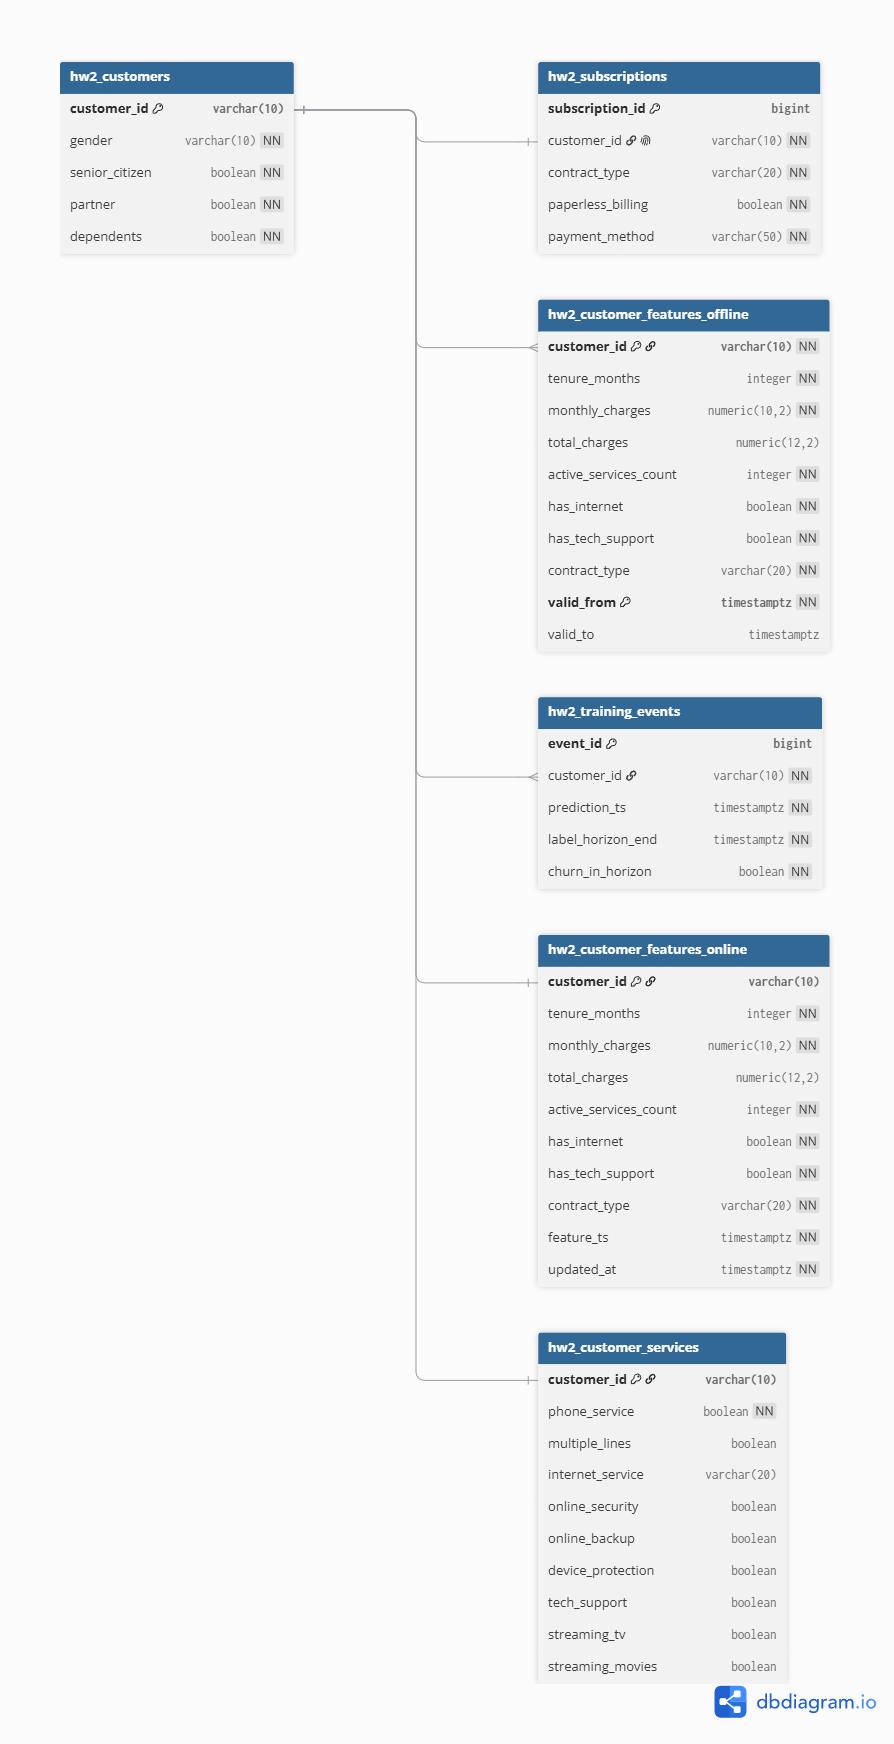

## Завдання 2. DDL у PostgreSQL

DDL нижче створює всі сутності та feature-таблиці разом з `PRIMARY KEY`, `FOREIGN KEY`, `NOT NULL`, доменними `CHECK`, temporal `CHECK` та індексами. На початку стоїть `DROP TABLE IF EXISTS ... CASCADE`, щоб `Restart & Run All` можна було прогнати повторно без ручного втручання.

> Синтаксис розрахований на PostgreSQL 16. Версія embedded `pgserver`, яку показано в збереженому запуску notebook, може бути новішою — на сумісність DDL це не впливає.


In [9]:
result = execute_sql("""
-- ============================================================
-- PostgreSQL 16
-- IBM Telco Customer Churn
-- ============================================================

SET TIME ZONE 'UTC';


-- ============================================================
-- DROP TABLES
-- Allows the notebook to be executed repeatedly
-- ============================================================

DROP TABLE IF EXISTS
    hw2_customer_features_online,
    hw2_training_events,
    hw2_customer_features_offline,
    hw2_customer_services,
    hw2_subscriptions,
    hw2_customers
CASCADE;


-- ============================================================
-- 1. CUSTOMERS
-- Natural business entity
-- ============================================================

CREATE TABLE hw2_customers (
    customer_id VARCHAR(10) PRIMARY KEY,

    gender VARCHAR(10) NOT NULL,

    senior_citizen BOOLEAN NOT NULL,
    partner BOOLEAN NOT NULL,
    dependents BOOLEAN NOT NULL,

    CONSTRAINT hw2_chk_customer_gender
        CHECK (gender IN ('Male', 'Female'))
);


-- ============================================================
-- 2. SUBSCRIPTIONS
-- Current subscription / billing configuration
-- One customer -> one subscription in our model
-- ============================================================

CREATE TABLE hw2_subscriptions (
    subscription_id BIGINT
        GENERATED BY DEFAULT AS IDENTITY
        PRIMARY KEY,

    customer_id VARCHAR(10) NOT NULL UNIQUE
        REFERENCES hw2_customers(customer_id),

    contract_type VARCHAR(20) NOT NULL,

    paperless_billing BOOLEAN NOT NULL,

    payment_method VARCHAR(50) NOT NULL,

    CONSTRAINT hw2_chk_subscription_contract
        CHECK (
            contract_type IN (
                'Month-to-month',
                'One year',
                'Two year'
            )
        ),

    CONSTRAINT hw2_chk_subscription_payment
        CHECK (
            payment_method IN (
                'Electronic check',
                'Mailed check',
                'Bank transfer (automatic)',
                'Credit card (automatic)'
            )
        )
);


-- ============================================================
-- 3. CUSTOMER SERVICES
-- Current services used by the customer
--
-- NULL has semantic meaning here:
--
-- multiple_lines IS NULL
--     => customer has no phone service
--
-- internet-related columns IS NULL
--     => customer has no internet service
-- ============================================================

CREATE TABLE hw2_customer_services (
    customer_id VARCHAR(10) PRIMARY KEY
        REFERENCES hw2_customers(customer_id),

    phone_service BOOLEAN NOT NULL,

    multiple_lines BOOLEAN,

    internet_service VARCHAR(20),

    online_security BOOLEAN,
    online_backup BOOLEAN,
    device_protection BOOLEAN,
    tech_support BOOLEAN,
    streaming_tv BOOLEAN,
    streaming_movies BOOLEAN,

    -- Internet service can only be DSL, Fiber optic,
    -- or NULL when the customer has no Internet service.
    CONSTRAINT hw2_chk_internet_service
        CHECK (
            internet_service IS NULL
            OR internet_service IN (
                'DSL',
                'Fiber optic'
            )
        ),

    -- MultipleLines only makes sense when PhoneService exists.
    CONSTRAINT hw2_chk_multiple_lines
        CHECK (
            (
                phone_service = TRUE
                AND multiple_lines IS NOT NULL
            )
            OR
            (
                phone_service = FALSE
                AND multiple_lines IS NULL
            )
        ),

    -- Internet add-on services are NULL when the
    -- customer has no Internet service.
    CONSTRAINT hw2_chk_internet_features
        CHECK (
            (
                internet_service IS NULL

                AND online_security IS NULL
                AND online_backup IS NULL
                AND device_protection IS NULL
                AND tech_support IS NULL
                AND streaming_tv IS NULL
                AND streaming_movies IS NULL
            )
            OR
            (
                internet_service IS NOT NULL

                AND online_security IS NOT NULL
                AND online_backup IS NOT NULL
                AND device_protection IS NOT NULL
                AND tech_support IS NOT NULL
                AND streaming_tv IS NOT NULL
                AND streaming_movies IS NOT NULL
            )
        )
);


-- ============================================================
-- 4. OFFLINE FEATURE STORE
--
-- Historical feature values.
--
-- One customer can have many feature versions.
-- Every version is valid on:
--
-- [valid_from, valid_to)
--
-- valid_to = NULL means current/open-ended version.
-- ============================================================

CREATE TABLE hw2_customer_features_offline (
    customer_id VARCHAR(10) NOT NULL
        REFERENCES hw2_customers(customer_id),

    tenure_months INTEGER NOT NULL,

    monthly_charges NUMERIC(10, 2) NOT NULL,

    total_charges NUMERIC(12, 2),

    active_services_count INTEGER NOT NULL,

    has_internet BOOLEAN NOT NULL,

    has_tech_support BOOLEAN NOT NULL,

    contract_type VARCHAR(20) NOT NULL,

    valid_from TIMESTAMPTZ NOT NULL,

    valid_to TIMESTAMPTZ,

    PRIMARY KEY (
        customer_id,
        valid_from
    ),

    CONSTRAINT hw2_chk_offline_tenure
        CHECK (tenure_months >= 0),

    CONSTRAINT hw2_chk_offline_monthly_charges
        CHECK (monthly_charges >= 0),

    CONSTRAINT hw2_chk_offline_total_charges
        CHECK (
            total_charges IS NULL
            OR total_charges >= 0
        ),

    CONSTRAINT hw2_chk_offline_services_count
        CHECK (active_services_count >= 0),

    CONSTRAINT hw2_chk_offline_contract
        CHECK (
            contract_type IN (
                'Month-to-month',
                'One year',
                'Two year'
            )
        ),

    -- Required temporal constraint
    CONSTRAINT hw2_chk_offline_valid_interval
        CHECK (
            valid_to IS NULL
            OR valid_to > valid_from
        )
);


-- ============================================================
-- Main AS-OF access pattern
--
-- Example:
-- WHERE customer_id = ?
--   AND valid_from <= prediction_ts
-- ============================================================

CREATE INDEX hw2_idx_customer_features_asof
    ON hw2_customer_features_offline
    (customer_id, valid_from DESC);


-- ============================================================
-- 5. TRAINING EVENTS
--
-- One row = one training example / prediction moment.
-- ============================================================

CREATE TABLE hw2_training_events (
    event_id BIGINT
        GENERATED BY DEFAULT AS IDENTITY
        PRIMARY KEY,

    customer_id VARCHAR(10) NOT NULL
        REFERENCES hw2_customers(customer_id),

    prediction_ts TIMESTAMPTZ NOT NULL,

    label_horizon_end TIMESTAMPTZ NOT NULL,

    churn_in_horizon BOOLEAN NOT NULL,

    CONSTRAINT hw2_chk_training_horizon
        CHECK (
            label_horizon_end > prediction_ts
        )
);


CREATE INDEX hw2_idx_training_events_customer_ts
    ON hw2_training_events
    (customer_id, prediction_ts);


-- ============================================================
-- 6. ONLINE FEATURE STORE
--
-- One current row per customer.
-- Optimized for lookup by customer_id.
-- ============================================================

CREATE TABLE hw2_customer_features_online (
    customer_id VARCHAR(10) PRIMARY KEY
        REFERENCES hw2_customers(customer_id),

    tenure_months INTEGER NOT NULL,

    monthly_charges NUMERIC(10, 2) NOT NULL,

    total_charges NUMERIC(12, 2),

    active_services_count INTEGER NOT NULL,

    has_internet BOOLEAN NOT NULL,

    has_tech_support BOOLEAN NOT NULL,

    contract_type VARCHAR(20) NOT NULL,

    feature_ts TIMESTAMPTZ NOT NULL,

    updated_at TIMESTAMPTZ NOT NULL
        DEFAULT CURRENT_TIMESTAMP,

    CONSTRAINT hw2_chk_online_tenure
        CHECK (tenure_months >= 0),

    CONSTRAINT hw2_chk_online_monthly_charges
        CHECK (monthly_charges >= 0),

    CONSTRAINT hw2_chk_online_total_charges
        CHECK (
            total_charges IS NULL
            OR total_charges >= 0
        ),

    CONSTRAINT hw2_chk_online_services_count
        CHECK (active_services_count >= 0),

    CONSTRAINT hw2_chk_online_contract
        CHECK (
            contract_type IN (
                'Month-to-month',
                'One year',
                'Two year'
            )
        ),

    CONSTRAINT hw2_chk_online_timestamps
        CHECK (
            updated_at >= feature_ts
        )
);
""")


Statement 1/10
-- ============================================================
-- PostgreSQL 16
-- IBM Telco Customer Churn
-- ============================================================

SET TIME ZONE 'UTC';
----------------------------------------------------------------------
Command executed successfully.

Statement 2/10
-- ============================================================
-- DROP TABLES
-- Allows the notebook to be executed repeatedly
-- ============================================================

DROP TABLE IF EXISTS
    hw2_customer_features_online,
    hw2_training_events,
    hw2_customer_features_offline,
    hw2_customer_services,
    hw2_subscriptions,
    hw2_customers
CASCADE;
----------------------------------------------------------------------
Command executed successfully.

Statement 3/10
-- ============================================================
-- 1. CUSTOMERS
-- Natural business entity
-- ==========================================================

## Завдання 3. Нормалізація

`hw2_customers`, `hw2_subscriptions`, `hw2_customer_services` та `hw2_training_events` я привів до 3НФ: атрибути в них атомарні, повністю залежать від ключа таблиці і не мають транзитивних залежностей одне від одного. Основні функціональні залежності, які я враховував під час декомпозиції: `customer_id → gender, senior_citizen, partner, dependents`; `subscription_id → customer_id, contract_type, paperless_billing, payment_method`; у `hw2_customer_services` весь набір сервісних атрибутів визначається `customer_id`; у `hw2_training_events` — `event_id` визначає всі поля події. У `hw2_subscriptions` колонка `customer_id` додатково має `UNIQUE`, тож у поточній моделі 1:1 вона теж виступає candidate key.

А от `hw2_customer_features_offline` і `hw2_customer_features_online` денормалізовані навмисно — це вже готовий feature vector, і частина колонок (`contract_type`, `has_internet`, `has_tech_support`, `active_services_count`) фактично дублює або агрегує дані з бізнесових таблиць. Такий вибір виправданий тим, як ці таблиці читаються: моделі потрібен весь набір ознак одним запитом за `customer_id`, без зайвих JOIN — саме це і дає низьку latency на online-рівні.

Плата за це — ризик розсинхронізації: якщо клієнт змінить контракт у `hw2_subscriptions`, online-таблиця якийсь час зберігатиме старий `contract_type`. Тому оновлення online-рівня не може бути довільним: після появи нової temporal-версії ознак актуальний рядок переноситься в `hw2_customer_features_online` через UPSERT, `feature_ts` фіксує момент, на який ознаки коректні, а `updated_at` — коли рядок реально оновили.


## Завдання 4. Point-in-Time correctness

Нижче я вручну зібрав невелику, але достатню temporal-історію ознак:
- 10 історичних рядків;
- 3 різні customer_id;
- для CUST000001 — аж 4 послідовні версії ознак підряд;
- усі часові мітки — TIMESTAMPTZ з явним `+00`;
- інтервали між версіями не перекриваються, а `valid_to` завжди строго більше за `valid_from` або дорівнює NULL для поточної версії.

`churn_in_horizon` тут — умовна цільова змінна, придумана саме для демонстрації логіки, а не реальний факт відтоку з IBM-датасету: у ньому, нагадаю, точного часу churn просто немає.


In [10]:
execute_sql("""
INSERT INTO hw2_customers (
    customer_id,
    gender,
    senior_citizen,
    partner,
    dependents
)
VALUES
    ('CUST000001', 'Male',   FALSE, TRUE,  FALSE),
    ('CUST000002', 'Female', TRUE,  FALSE, FALSE),
    ('CUST000003', 'Female', FALSE, TRUE,  TRUE);
""")


Statement 1/1
INSERT INTO hw2_customers (
    customer_id,
    gender,
    senior_citizen,
    partner,
    dependents
)
VALUES
    ('CUST000001', 'Male',   FALSE, TRUE,  FALSE),
    ('CUST000002', 'Female', TRUE,  FALSE, FALSE),
    ('CUST000003', 'Female', FALSE, TRUE,  TRUE);
----------------------------------------------------------------------
Command executed successfully. Rows affected: 3

Finished successfully: 1 statement(s) executed.


In [11]:
execute_sql("""
INSERT INTO hw2_subscriptions (
    customer_id,
    contract_type,
    paperless_billing,
    payment_method
)
VALUES
    (
        'CUST000001',
        'Month-to-month',
        TRUE,
        'Electronic check'
    ),
    (
        'CUST000002',
        'One year',
        TRUE,
        'Credit card (automatic)'
    ),
    (
        'CUST000003',
        'Two year',
        FALSE,
        'Bank transfer (automatic)'
    );
""")


Statement 1/1
INSERT INTO hw2_subscriptions (
    customer_id,
    contract_type,
    paperless_billing,
    payment_method
)
VALUES
    (
        'CUST000001',
        'Month-to-month',
        TRUE,
        'Electronic check'
    ),
    (
        'CUST000002',
        'One year',
        TRUE,
        'Credit card (automatic)'
    ),
    (
        'CUST000003',
        'Two year',
        FALSE,
        'Bank transfer (automatic)'
    );
----------------------------------------------------------------------
Command executed successfully. Rows affected: 3

Finished successfully: 1 statement(s) executed.


In [12]:
execute_sql("""
INSERT INTO hw2_customer_services (
    customer_id,
    phone_service,
    multiple_lines,
    internet_service,
    online_security,
    online_backup,
    device_protection,
    tech_support,
    streaming_tv,
    streaming_movies
)
VALUES
(
    'CUST000001',
    TRUE,
    TRUE,
    'Fiber optic',
    FALSE,
    TRUE,
    TRUE,
    FALSE,
    TRUE,
    TRUE
),
(
    'CUST000002',
    TRUE,
    FALSE,
    'DSL',
    TRUE,
    TRUE,
    FALSE,
    TRUE,
    FALSE,
    FALSE
),
(
    'CUST000003',
    FALSE,
    NULL,
    NULL,
    NULL,
    NULL,
    NULL,
    NULL,
    NULL,
    NULL
);
""")


Statement 1/1
INSERT INTO hw2_customer_services (
    customer_id,
    phone_service,
    multiple_lines,
    internet_service,
    online_security,
    online_backup,
    device_protection,
    tech_support,
    streaming_tv,
    streaming_movies
)
VALUES
(
    'CUST000001',
    TRUE,
    TRUE,
    'Fiber optic',
    FALSE,
    TRUE,
    TRUE,
    FALSE,
    TRUE,
    TRUE
),
(
    'CUST000002',
    TRUE,
    FALSE,
    'DSL',
    TRUE,
    TRUE,
    FALSE,
    TRUE,
    FALSE,
    FALSE
),
(
    'CUST000003',
    FALSE,
    NULL,
    NULL,
    NULL,
    NULL,
    NULL,
    NULL,
    NULL,
    NULL
);
----------------------------------------------------------------------
Command executed successfully. Rows affected: 3

Finished successfully: 1 statement(s) executed.


In [13]:
execute_sql("""
INSERT INTO hw2_customer_features_offline (
    customer_id,
    tenure_months,
    monthly_charges,
    total_charges,
    active_services_count,
    has_internet,
    has_tech_support,
    contract_type,
    valid_from,
    valid_to
)
VALUES

-- ============================================================
-- Customer 1: 4 historical versions
-- ============================================================

(
    'CUST000001',
    3,
    49.90,
    149.70,
    3,
    TRUE,
    FALSE,
    'Month-to-month',
    TIMESTAMPTZ '2024-01-01 00:00:00+00',
    TIMESTAMPTZ '2024-04-01 00:00:00+00'
),

(
    'CUST000001',
    6,
    59.90,
    329.40,
    4,
    TRUE,
    FALSE,
    'Month-to-month',
    TIMESTAMPTZ '2024-04-01 00:00:00+00',
    TIMESTAMPTZ '2024-07-01 00:00:00+00'
),

(
    'CUST000001',
    9,
    69.90,
    539.10,
    5,
    TRUE,
    TRUE,
    'Month-to-month',
    TIMESTAMPTZ '2024-07-01 00:00:00+00',
    TIMESTAMPTZ '2024-10-01 00:00:00+00'
),

(
    'CUST000001',
    12,
    74.90,
    763.80,
    6,
    TRUE,
    TRUE,
    'One year',
    TIMESTAMPTZ '2024-10-01 00:00:00+00',
    NULL
),


-- ============================================================
-- Customer 2: 3 historical versions
-- ============================================================

(
    'CUST000002',
    12,
    54.00,
    648.00,
    3,
    TRUE,
    TRUE,
    'One year',
    TIMESTAMPTZ '2024-01-15 00:00:00+00',
    TIMESTAMPTZ '2024-05-15 00:00:00+00'
),

(
    'CUST000002',
    16,
    58.00,
    880.00,
    4,
    TRUE,
    TRUE,
    'One year',
    TIMESTAMPTZ '2024-05-15 00:00:00+00',
    TIMESTAMPTZ '2024-09-15 00:00:00+00'
),

(
    'CUST000002',
    20,
    62.00,
    1128.00,
    4,
    TRUE,
    TRUE,
    'One year',
    TIMESTAMPTZ '2024-09-15 00:00:00+00',
    NULL
),


-- ============================================================
-- Customer 3: 3 historical versions
-- ============================================================

(
    'CUST000003',
    24,
    20.00,
    480.00,
    1,
    FALSE,
    FALSE,
    'Two year',
    TIMESTAMPTZ '2024-02-01 00:00:00+00',
    TIMESTAMPTZ '2024-06-01 00:00:00+00'
),

(
    'CUST000003',
    28,
    22.00,
    568.00,
    1,
    FALSE,
    FALSE,
    'Two year',
    TIMESTAMPTZ '2024-06-01 00:00:00+00',
    TIMESTAMPTZ '2024-10-01 00:00:00+00'
),

(
    'CUST000003',
    32,
    25.00,
    668.00,
    1,
    FALSE,
    FALSE,
    'Two year',
    TIMESTAMPTZ '2024-10-01 00:00:00+00',
    NULL
);
""")


Statement 1/1
INSERT INTO hw2_customer_features_offline (
    customer_id,
    tenure_months,
    monthly_charges,
    total_charges,
    active_services_count,
    has_internet,
    has_tech_support,
    contract_type,
    valid_from,
    valid_to
)
VALUES

-- ============================================================
-- Customer 1: 4 historical versions
-- ============================================================

(
    'CUST000001',
    3,
    49.90,
    149.70,
    3,
    TRUE,
    FALSE,
    'Month-to-month',
    TIMESTAMPTZ '2024-01-01 00:00:00+00',
    TIMESTAMPTZ '2024-04-01 00:00:00+00'
),

(
    'CUST000001',
    6,
    59.90,
    329.40,
    4,
    TRUE,
    FALSE,
    'Month-to-month',
    TIMESTAMPTZ '2024-04-01 00:00:00+00',
    TIMESTAMPTZ '2024-07-01 00:00:00+00'
),

(
    'CUST000001',
    9,
    69.90,
    539.10,
    5,
    TRUE,
    TRUE,
    'Month-to-month',
    TIMESTAMPTZ '2024-07-01 00:00:00+00',
    TIMESTAMPTZ '2024-10-01 00:00:00+00'
),

(
    'CUST000

In [14]:
execute_sql("""
INSERT INTO hw2_training_events (
    customer_id,
    prediction_ts,
    label_horizon_end,
    churn_in_horizon
)
VALUES

-- Customer 1: should select version 1
(
    'CUST000001',
    TIMESTAMPTZ '2024-02-15 10:00:00+00',
    TIMESTAMPTZ '2024-03-15 10:00:00+00',
    FALSE
),

-- Customer 1: should select version 2
(
    'CUST000001',
    TIMESTAMPTZ '2024-05-10 10:00:00+00',
    TIMESTAMPTZ '2024-06-10 10:00:00+00',
    FALSE
),

-- Customer 1: should select version 3
(
    'CUST000001',
    TIMESTAMPTZ '2024-08-20 10:00:00+00',
    TIMESTAMPTZ '2024-09-20 10:00:00+00',
    TRUE
),

-- Customer 1: should select current/latest version
(
    'CUST000001',
    TIMESTAMPTZ '2024-11-15 10:00:00+00',
    TIMESTAMPTZ '2024-12-15 10:00:00+00',
    FALSE
),

-- Customer 2: version 1
(
    'CUST000002',
    TIMESTAMPTZ '2024-03-01 10:00:00+00',
    TIMESTAMPTZ '2024-04-01 10:00:00+00',
    FALSE
),

-- Customer 2: version 2
(
    'CUST000002',
    TIMESTAMPTZ '2024-07-01 10:00:00+00',
    TIMESTAMPTZ '2024-08-01 10:00:00+00',
    TRUE
),

-- Customer 2: version 3
(
    'CUST000002',
    TIMESTAMPTZ '2024-11-01 10:00:00+00',
    TIMESTAMPTZ '2024-12-01 10:00:00+00',
    FALSE
),

-- Customer 3: version 1
(
    'CUST000003',
    TIMESTAMPTZ '2024-04-01 10:00:00+00',
    TIMESTAMPTZ '2024-05-01 10:00:00+00',
    FALSE
),

-- Customer 3: version 2
(
    'CUST000003',
    TIMESTAMPTZ '2024-08-01 10:00:00+00',
    TIMESTAMPTZ '2024-09-01 10:00:00+00',
    FALSE
),

-- Customer 3: version 3
(
    'CUST000003',
    TIMESTAMPTZ '2024-12-01 10:00:00+00',
    TIMESTAMPTZ '2025-01-01 10:00:00+00',
    TRUE
);
""")


Statement 1/1
INSERT INTO hw2_training_events (
    customer_id,
    prediction_ts,
    label_horizon_end,
    churn_in_horizon
)
VALUES

-- Customer 1: should select version 1
(
    'CUST000001',
    TIMESTAMPTZ '2024-02-15 10:00:00+00',
    TIMESTAMPTZ '2024-03-15 10:00:00+00',
    FALSE
),

-- Customer 1: should select version 2
(
    'CUST000001',
    TIMESTAMPTZ '2024-05-10 10:00:00+00',
    TIMESTAMPTZ '2024-06-10 10:00:00+00',
    FALSE
),

-- Customer 1: should select version 3
(
    'CUST000001',
    TIMESTAMPTZ '2024-08-20 10:00:00+00',
    TIMESTAMPTZ '2024-09-20 10:00:00+00',
    TRUE
),

-- Customer 1: should select current/latest version
(
    'CUST000001',
    TIMESTAMPTZ '2024-11-15 10:00:00+00',
    TIMESTAMPTZ '2024-12-15 10:00:00+00',
    FALSE
),

-- Customer 2: version 1
(
    'CUST000002',
    TIMESTAMPTZ '2024-03-01 10:00:00+00',
    TIMESTAMPTZ '2024-04-01 10:00:00+00',
    FALSE
),

-- Customer 2: version 2
(
    'CUST000002',
    TIMESTAMPTZ '2024-07-01 10:00

In [15]:
execute_sql("""
INSERT INTO hw2_customer_features_online (
    customer_id,
    tenure_months,
    monthly_charges,
    total_charges,
    active_services_count,
    has_internet,
    has_tech_support,
    contract_type,
    feature_ts,
    updated_at
)
VALUES
(
    'CUST000001',
    12,
    74.90,
    763.80,
    6,
    TRUE,
    TRUE,
    'One year',
    TIMESTAMPTZ '2024-10-01 00:00:00+00',
    TIMESTAMPTZ '2024-10-01 00:05:00+00'
),
(
    'CUST000002',
    20,
    62.00,
    1128.00,
    4,
    TRUE,
    TRUE,
    'One year',
    TIMESTAMPTZ '2024-09-15 00:00:00+00',
    TIMESTAMPTZ '2024-09-15 00:05:00+00'
),
(
    'CUST000003',
    32,
    25.00,
    668.00,
    1,
    FALSE,
    FALSE,
    'Two year',
    TIMESTAMPTZ '2024-10-01 00:00:00+00',
    TIMESTAMPTZ '2024-10-01 00:05:00+00'
);
""")


Statement 1/1
INSERT INTO hw2_customer_features_online (
    customer_id,
    tenure_months,
    monthly_charges,
    total_charges,
    active_services_count,
    has_internet,
    has_tech_support,
    contract_type,
    feature_ts,
    updated_at
)
VALUES
(
    'CUST000001',
    12,
    74.90,
    763.80,
    6,
    TRUE,
    TRUE,
    'One year',
    TIMESTAMPTZ '2024-10-01 00:00:00+00',
    TIMESTAMPTZ '2024-10-01 00:05:00+00'
),
(
    'CUST000002',
    20,
    62.00,
    1128.00,
    4,
    TRUE,
    TRUE,
    'One year',
    TIMESTAMPTZ '2024-09-15 00:00:00+00',
    TIMESTAMPTZ '2024-09-15 00:05:00+00'
),
(
    'CUST000003',
    32,
    25.00,
    668.00,
    1,
    FALSE,
    FALSE,
    'Two year',
    TIMESTAMPTZ '2024-10-01 00:00:00+00',
    TIMESTAMPTZ '2024-10-01 00:05:00+00'
);
----------------------------------------------------------------------
Command executed successfully. Rows affected: 3

Finished successfully: 1 statement(s) executed.


In [16]:
execute_sql("""
SELECT
    customer_id,
    COUNT(*) AS version_count
FROM hw2_customer_features_offline
GROUP BY customer_id
ORDER BY customer_id;
""")


Statement 1/1
SELECT
    customer_id,
    COUNT(*) AS version_count
FROM hw2_customer_features_offline
GROUP BY customer_id
ORDER BY customer_id;
----------------------------------------------------------------------


,customer_id,version_count
0,CUST000001,4
1,CUST000002,3
2,CUST000003,3



Finished successfully: 1 statement(s) executed.


In [17]:
execute_sql("""
SELECT COUNT(*) AS historical_rows
FROM hw2_customer_features_offline;
""")


Statement 1/1
SELECT COUNT(*) AS historical_rows
FROM hw2_customer_features_offline;
----------------------------------------------------------------------


,historical_rows
0,10



Finished successfully: 1 statement(s) executed.


### AS-OF запити та контроль temporal-інтервалів

Далі йдуть чотири перевірки:
1. AS-OF SELECT для моменту всередині одного з історичних інтервалів;
2. AS-OF SELECT точно на межі між двома сусідніми версіями;
3. AS-OF JOIN, який зв'язує `hw2_training_events` з `hw2_customer_features_offline` за `prediction_ts`;
4. запит на перекривання інтервалів — правильний результат тут один: 0 рядків.


In [18]:
execute_sql("""
SELECT
    customer_id,
    tenure_months,
    monthly_charges,
    total_charges,
    active_services_count,
    has_internet,
    has_tech_support,
    contract_type,
    valid_from,
    valid_to
FROM hw2_customer_features_offline
WHERE customer_id = 'CUST000001'
  AND valid_from <= TIMESTAMPTZ '2024-02-15 10:00:00+00'
  AND (
      valid_to > TIMESTAMPTZ '2024-02-15 10:00:00+00'
      OR valid_to IS NULL
  );
""")


Statement 1/1
SELECT
    customer_id,
    tenure_months,
    monthly_charges,
    total_charges,
    active_services_count,
    has_internet,
    has_tech_support,
    contract_type,
    valid_from,
    valid_to
FROM hw2_customer_features_offline
WHERE customer_id = 'CUST000001'
  AND valid_from <= TIMESTAMPTZ '2024-02-15 10:00:00+00'
  AND (
      valid_to > TIMESTAMPTZ '2024-02-15 10:00:00+00'
      OR valid_to IS NULL
  );
----------------------------------------------------------------------


,customer_id,tenure_months,monthly_charges,total_charges,active_services_count,has_internet,has_tech_support,contract_type,valid_from,valid_to
0,CUST000001,3,49.90,149.70,3,True,False,Month-to-month,2024-01-01 00:00:00+00:00,2024-04-01 00:00:00+00:00



Finished successfully: 1 statement(s) executed.


In [19]:
execute_sql("""
SELECT
    customer_id,
    tenure_months,
    monthly_charges,
    total_charges,
    active_services_count,
    has_internet,
    has_tech_support,
    contract_type,
    valid_from,
    valid_to
FROM hw2_customer_features_offline
WHERE customer_id = 'CUST000001'
  AND valid_from <= TIMESTAMPTZ '2024-10-01 00:00:00+00'
  AND (
      valid_to > TIMESTAMPTZ '2024-10-01 00:00:00+00'
      OR valid_to IS NULL
  );
""")


Statement 1/1
SELECT
    customer_id,
    tenure_months,
    monthly_charges,
    total_charges,
    active_services_count,
    has_internet,
    has_tech_support,
    contract_type,
    valid_from,
    valid_to
FROM hw2_customer_features_offline
WHERE customer_id = 'CUST000001'
  AND valid_from <= TIMESTAMPTZ '2024-10-01 00:00:00+00'
  AND (
      valid_to > TIMESTAMPTZ '2024-10-01 00:00:00+00'
      OR valid_to IS NULL
  );
----------------------------------------------------------------------


,customer_id,tenure_months,monthly_charges,total_charges,active_services_count,has_internet,has_tech_support,contract_type,valid_from,valid_to
0,CUST000001,12,74.90,763.80,6,True,True,One year,2024-10-01 00:00:00+00:00,None



Finished successfully: 1 statement(s) executed.


In [20]:
execute_sql("""
SELECT
    e.event_id,
    e.customer_id,
    e.prediction_ts,
    e.label_horizon_end,
    e.churn_in_horizon,

    f.tenure_months,
    f.monthly_charges,
    f.total_charges,
    f.active_services_count,
    f.has_internet,
    f.has_tech_support,
    f.contract_type,

    f.valid_from,
    f.valid_to

FROM hw2_training_events AS e

LEFT JOIN hw2_customer_features_offline AS f
    ON f.customer_id = e.customer_id
   AND f.valid_from <= e.prediction_ts
   AND (
       f.valid_to > e.prediction_ts
       OR f.valid_to IS NULL
   )

ORDER BY e.event_id;
""")


Statement 1/1
SELECT
    e.event_id,
    e.customer_id,
    e.prediction_ts,
    e.label_horizon_end,
    e.churn_in_horizon,

    f.tenure_months,
    f.monthly_charges,
    f.total_charges,
    f.active_services_count,
    f.has_internet,
    f.has_tech_support,
    f.contract_type,

    f.valid_from,
    f.valid_to

FROM hw2_training_events AS e

LEFT JOIN hw2_customer_features_offline AS f
    ON f.customer_id = e.customer_id
   AND f.valid_from <= e.prediction_ts
   AND (
       f.valid_to > e.prediction_ts
       OR f.valid_to IS NULL
   )

ORDER BY e.event_id;
----------------------------------------------------------------------


,event_id,customer_id,prediction_ts,label_horizon_end,churn_in_horizon,tenure_months,monthly_charges,total_charges,active_services_count,has_internet,has_tech_support,contract_type,valid_from,valid_to
0,1,CUST000001,2024-02-15 10:00:00+00:00,2024-03-15 10:00:00+00:00,False,3,49.90,149.70,3,True,False,Month-to-month,2024-01-01 00:00:00+00:00,2024-04-01 00:00:00+00:00
1,2,CUST000001,2024-05-10 10:00:00+00:00,2024-06-10 10:00:00+00:00,False,6,59.90,329.40,4,True,False,Month-to-month,2024-04-01 00:00:00+00:00,2024-07-01 00:00:00+00:00
2,3,CUST000001,2024-08-20 10:00:00+00:00,2024-09-20 10:00:00+00:00,True,9,69.90,539.10,5,True,True,Month-to-month,2024-07-01 00:00:00+00:00,2024-10-01 00:00:00+00:00
3,4,CUST000001,2024-11-15 10:00:00+00:00,2024-12-15 10:00:00+00:00,False,12,74.90,763.80,6,True,True,One year,2024-10-01 00:00:00+00:00,NaT
4,5,CUST000002,2024-03-01 10:00:00+00:00,2024-04-01 10:00:00+00:00,False,12,54.00,648.00,3,True,True,One year,2024-01-15 00:00:00+00:00,2024-05-15 00:00:00+00:00
5,6,CUST000002,2024-07-01 10:00:00+00:00,2024-08-01 10:00:00+00:00,True,16,58.00,880.00,4,True,True,One year,2024-05-15 00:00:00+00:00,2024-09-15 00:00:00+00:00
6,7,CUST000002,2024-11-01 10:00:00+00:00,2024-12-01 10:00:00+00:00,False,20,62.00,1128.00,4,True,True,One year,2024-09-15 00:00:00+00:00,NaT
7,8,CUST000003,2024-04-01 10:00:00+00:00,2024-05-01 10:00:00+00:00,False,24,20.00,480.00,1,False,False,Two year,2024-02-01 00:00:00+00:00,2024-06-01 00:00:00+00:00
8,9,CUST000003,2024-08-01 10:00:00+00:00,2024-09-01 10:00:00+00:00,False,28,22.00,568.00,1,False,False,Two year,2024-06-01 00:00:00+00:00,2024-10-01 00:00:00+00:00
9,10,CUST000003,2024-12-01 10:00:00+00:00,2025-01-01 10:00:00+00:00,True,32,25.00,668.00,1,False,False,Two year,2024-10-01 00:00:00+00:00,NaT



Finished successfully: 1 statement(s) executed.


In [21]:
execute_sql("""
SELECT
    a.customer_id,
    a.valid_from AS a_from,
    a.valid_to   AS a_to,
    b.valid_from AS b_from,
    b.valid_to   AS b_to
FROM hw2_customer_features_offline AS a
JOIN hw2_customer_features_offline AS b
    ON a.customer_id = b.customer_id

    -- interval A starts before interval B ends
    AND a.valid_from <
        COALESCE(
            b.valid_to,
            'infinity'::timestamptz
        )

    -- interval B starts before interval A ends
    AND b.valid_from <
        COALESCE(
            a.valid_to,
            'infinity'::timestamptz
        )

    -- prevents comparing the same pair twice
    AND a.valid_from < b.valid_from

ORDER BY
    a.customer_id,
    a.valid_from,
    b.valid_from;
""")


Statement 1/1
SELECT
    a.customer_id,
    a.valid_from AS a_from,
    a.valid_to   AS a_to,
    b.valid_from AS b_from,
    b.valid_to   AS b_to
FROM hw2_customer_features_offline AS a
JOIN hw2_customer_features_offline AS b
    ON a.customer_id = b.customer_id

    -- interval A starts before interval B ends
    AND a.valid_from <
        COALESCE(
            b.valid_to,
            'infinity'::timestamptz
        )

    -- interval B starts before interval A ends
    AND b.valid_from <
        COALESCE(
            a.valid_to,
            'infinity'::timestamptz
        )

    -- prevents comparing the same pair twice
    AND a.valid_from < b.valid_from

ORDER BY
    a.customer_id,
    a.valid_from,
    b.valid_from;
----------------------------------------------------------------------


,customer_id,a_from,a_to,b_from,b_to



Finished successfully: 1 statement(s) executed.


### Пояснення Point-in-Time correctness

Умова `valid_from <= prediction_ts` потрібна, щоб у вибірку потрапляла лише та версія ознак, яка вже існувала на момент, коли робився прогноз, — версії з майбутнього (де `valid_from` пізніше за `prediction_ts`) відсікаються одразу. Верхня межа `valid_to > prediction_ts OR valid_to IS NULL` перевіряє, що ця версія на той момент ще не «закрилась»: перша частина умови ловить випадок, коли версію вже змінили пізніше, а `NULL` — це відкрита, досі чинна версія.

Інтервали я трактую як напіввідкриті — `[valid_from, valid_to)`. Момент `valid_from` вже належить новій версії, а `valid_to` — ще ні, він належить наступній. Завдяки цьому дві сусідні версії можуть стикатися рівно в одній точці (наприклад, `[2024-01-01, 2024-04-01)` і одразу `[2024-04-01, 2024-07-01)`), і жоден момент часу при цьому не потрапляє одразу в дві версії.

Якби замість AS-OF-умови я просто з'єднав `hw2_training_events` з `hw2_customer_features_offline` по `customer_id`, кожна подія отримала б усі версії ознак клієнта одразу — і минулі, і майбутні відносно `prediction_ts`. Це одразу дві проблеми: по-перше, дублікати training-прикладів (одна подія — кілька рядків ознак), по-друге, у ці рядки потраплять значення, яких на момент прогнозу ще не існувало. Наприклад, подія з травня могла б «побачити» зміну тарифу чи контракту, що сталася аж у жовтні. Модель тоді фактично вчиться на інформації з майбутнього — це і є data leakage, і саме він завищує метрики на валідації, які потім не підтверджуються в проді.

Запит на перевірку перекривань за задумом має повертати нуль рядків, і на збережених тестових даних це підтверджується — DataFrame порожній.


## Завдання 5. Reflection

Найважче в цій роботі виявилося не проєктування сутностей саме по собі, а point-in-time correctness. Вибрати `customers`, `subscriptions` і `customer_services` та розписати кардинальності було відносно прямолінійно — вони описують поточний стан клієнта, і зв'язки між ними доволі очевидні. А от коли доходить до feature store, легко випадково «підглянути» в майбутнє: одна неправильна умова в JOIN — і модель під час навчання бачить дані, яких на момент прогнозу ще не існувало. IBM-датасет тут не допомагає, бо в ньому немає реальної temporal-історії, тож усю логіку `prediction_ts` / `valid_from` / `valid_to` довелося продумувати і тестувати на власноруч зібраних даних.

Головний компроміс — це поєднання нормалізованої бізнес-частини з денормалізованим feature store. `hw2_customers`, `hw2_subscriptions`, `hw2_customer_services` і `hw2_training_events` лишаються нормалізованими, а offline- та online-таблиці ознак навмисно зберігають готовий, частково дубльований набір значень. Це узгоджується з тим, як ці дані фактично читають: для навчання потрібен AS-OF lookup по історії, а для online-прогнозу — миттєвий доступ до одного рядка за `customer_id`, без ланцюжка JOIN.

Якби online-lookup мав обслуговувати справді велику кількість користувачів, я лишив би ту саму ідею — один денормалізований рядок на клієнта, — але додав би шар кешування перед базою, попередньо матеріалізовував ознаки батчем, а не по запиту, і, за потреби, шардив дані за `customer_id`. Свіжість даних контролював би через `feature_ts`/`updated_at` і моніторинг лагу між offline- і online-оновленням.

Щодо горизонту в шість місяців — ризики цілком реальні: ознаки перейменують, зміняться типи або сама семантика фічі (наприклад, `tenure_months` порахують по-іншому), якісь колонки приберуть. Найнеприємніше — зламати сумісність зі старими моделями, вже натренованими на попередній версії схеми. Тому зміни варто версіонувати, не переозначати існуючі фічі «на місці» і зберігати можливість відтворити той самий training dataset, на якому модель навчалась раніше.


## Висновки

У підсумку вийшла реляційна схема для сценарію Customer Churn, побудована на поняттях з IBM Telco Customer Churn, де бізнес-сутності чітко відокремлені від offline- і online-рівнів feature store. DDL у PostgreSQL включає PRIMARY KEY, FOREIGN KEY, NOT NULL, доменні CHECK, temporal CHECK на `valid_from`/`valid_to` та індекси під основні патерни доступу.

Для перевірки point-in-time correctness я підготував 10 історичних feature-записів на трьох клієнтів, причому в одного з них — чотири послідовні версії ознак. AS-OF запити щоразу підбирають саме ту версію, яка була чинною на `prediction_ts`, а окремий запит на перекривання інтервалів повертає нуль рядків — отже, навчальні приклади не використовують значення ознак із майбутнього.

Offline-рівень зберігає повну історію, потрібну для відтворюваного навчання моделі, а online-рівень — це вже готовий денормалізований рядок під швидкий prediction. Сама temporal-історія тут повністю контрольована й придумана для демонстрації: вихідний IBM-датасет — це один зріз у часі, без точного моменту відтоку клієнта.


## Самоперевірка перед здачею

- ✅ ER-діаграма є в notebook (і зображенням, і DBML-кодом).
- ✅ Три природні сутності, з ключами, FK і позначеними кардинальностями.
- ✅ Offline- і online-рівні feature store розведені по окремих таблицях.
- ✅ Пояснено, чому в моделі немає штучної N:M bridge-таблиці.
- ✅ У DDL є PK, FK, NOT NULL, доменні CHECK, temporal CHECK і індекси.
- ✅ У feature-таблиці є valid_from / valid_to.
- ✅ 10 історичних рядків на 3 customer_id.
- ✅ В одного customer_id — 4 послідовні версії ознак.
- ✅ 3 AS-OF SELECT-запити, один з них — AS-OF JOIN для training data.
- ✅ Перевірка на перекривання інтервалів повертає 0 рядків.
- ✅ Пояснено 3НФ, денормалізацію, point-in-time логіку і ризик data leakage.
- ✅ Reflection (~250–300 слів) і висновки на місці.

> Перед тим як здавати в LMS, ще раз прогнати Runtime → Restart session and run all (Restart & Run All) у Colab, щоб переконатися, що все відпрацьовує з чистого середовища без помилок.
